# 06_10 - per-gene isoform entropy with an UNCONDITIONAL denominator, isoform level

In [1]:
# relocation-proof bootstrap
import os
import sys

_d = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_d, '.notebooks_root')):
    _p = os.path.dirname(_d)
    if _p == _d:
        raise RuntimeError('could not locate .notebooks_root above this notebook')
    _d = _p
os.chdir(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)
print('working dir:', os.getcwd())

import gc
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.sparse import issparse, csr_matrix
import matplotlib
import matplotlib.pyplot as plt

import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath
import senescence_robustness as sr
importlib.reload(sr)

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.width', 240)

working dir: /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks


In [2]:
# preferred plot formatting
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0
plt.rcParams.update({
    'font.size': 6, 'axes.titlesize': 6, 'axes.labelsize': 6,
    'xtick.labelsize': 6, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'legend.title_fontsize': 6,
    'legend.labelspacing': 0.1, 'legend.borderpad': 0.3, 'legend.handletextpad': 0.2,
    'figure.titlesize': 6,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'figure.titleweight': 'bold',
    'xtick.major.size': TICK_LEN, 'ytick.major.size': TICK_LEN,
    'xtick.major.pad': TICK_LABEL_PAD, 'ytick.major.pad': TICK_LABEL_PAD,
    'axes.labelpad': AXIS_LABEL_PAD,
})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

UP_COLOR = '#c44e52'
DOWN_COLOR = '#4c72b0'
NS_COLOR = '#bdbdbd'

H5AD_DIR = '../pacbio/h5ads'
CSV_DIR = '../csvs'
OUT = CSV_DIR + '/06_36_robustness'
os.makedirs(OUT, exist_ok=True)
OBJ = (H5AD_DIR + '/all_samples_pacbio_recollapsed_raw_counts_ensemblids_annotatedonly'
       '_bc_anndata_preprocessed_with_isofrac_xgen_cdkn2a.h5ad')
STATUS_COL = 'xgen_cdkn2a_raw_status'

# --- THE ONE PARAMETER THAT DEFINES THIS NOTEBOOK --------------------------------
# 1 -> unconditional: every cell expressing the gene contributes, and a cell detecting a
#      single isoform contributes its true entropy, which is 0.
# 2 -> reproduces 06_46c exactly. Both are computed in one pass regardless (see below);
#      this only selects which one is treated as primary.
MIN_ISOFORMS_FOR_DENOMINATOR = 1

MIN_CELLS_PER_ARM = 5      # per gene, per arm, on the PRIMARY denominator
# Gates the per-donor arm of the reproducibility filter in sections 6 and 8.
# `reproducible` is what 06_51/06_52 filter on and Fig. 4E draws, so this gate is
# load-bearing. Matches 06_11's constant of the same name.
MIN_CELLS_PER_ARM_DONOR = 10   # per (gene, donor) arm, for the concordance filter
# Moved here from section 8b (the Fig. 4F panel), where they were defined mid-run.
# BOTH are applied when DONOR_GATE = 'both' (the default). Under the old
# 'match_volcano' setting MIN_CELLS_PER_GROUP was declared but never read.
MIN_CELLS_PER_GROUP = 5        # per donor, cells with >= 2 isoforms, for the boxes
MIN_EXPR_CELLS_PER_GROUP = 10  # per donor, cells EXPRESSING the gene
N_PERM = 1000
CHUNK = 4000

# cross-donor reproducibility, carried over from 06_46c unchanged. The criterion is
#     (sign_pos >= k) or (sign_neg >= k)
# and sign_pos + sign_neg = n_donors, so one side ALWAYS holds at least ceil(n/2): a
# threshold at or below ceil(MIN_DONORS_ESTIMABLE / 2) excludes nothing. At
# MIN_DONORS_ESTIMABLE = 3, only 3 is non-vacuous. The guard below re-checks this.
MIN_DONORS_ESTIMABLE = 3
MIN_DONORS_CONCORDANT = 3

final = {}
print(f'denominator: cells with >= {MIN_ISOFORMS_FOR_DENOMINATOR} isoform(s) detected '
      f'({"UNCONDITIONAL" if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else "conditional, = 06_46c"})')

denominator: cells with >= 1 isoform(s) detected (UNCONDITIONAL)


## 1. Load and accumulate


In [3]:
import scanpy as sc
adata = sc.read_h5ad(OBJ)
st = adata.obs[STATUS_COL].astype(str)
adata = adata[(~st.isin(['other_CDKN2A+', 'p14ARF+'])).values].copy()
st = adata.obs[STATUS_COL].astype(str)
sen = st.isin(['p16+', 'Both']).values

gene_col = ('pigeon_associated_gene' if 'pigeon_associated_gene' in adata.var.columns
            else 'gene_name')
adata = adata[:, adata.var[gene_col].notna().values].copy()
iso_to_gene, gene_of_iso, genes, _ = sr.build_iso_to_gene(adata.var[gene_col].values)
n_genes = len(genes)
donor = adata.obs['donor'].astype(str).values
tube = adata.obs['tube_id'].astype(str).values
donors = sorted(set(donor))
print(f'{adata.n_obs:,} cells x {adata.n_vars:,} isoforms -> {n_genes:,} genes')
print(f'senescent {int(sen.sum()):,}   donors {donors}')

# permutation labels: shuffle senescence WITHIN SAMPLE, preserving the blocking and the
# per-sample arm sizes. Row N_PERM carries the TRUE labels and is used to prove the
# vectorised path reproduces the observed accumulators, then dropped.
#
# NOTE ON WHAT THIS NULL DOES NOT DO. Permuting the label assigns "senescent" to cells of
# average depth, while the real senescent arm is ~2.4x deeper. The null therefore describes
# "no senescence signal AND no depth gap", and any excess over it carries both. That is true
# of 06_46c as well; it matters more here because the detection term is depth's main entry
# point and this notebook promotes that term to the dominant one.
rng = np.random.default_rng(0)
block_idx = [np.where(tube == k)[0] for k in np.unique(tube)]
perm_labels = np.zeros((N_PERM + 1, len(sen)), dtype=bool)
for r in range(N_PERM):
    lab = sen.copy()
    for idx in block_idx:
        lab[idx] = rng.permutation(sen[idx])
    perm_labels[r] = lab
perm_labels[N_PERM] = sen
print(f'permutation blocks: {len(block_idx)} samples')

frac = adata.layers['isoform_fraction']
frac = frac.tocsr() if issparse(frac) else csr_matrix(frac)

# observed accumulators: [arm, gene], arm 0 = reference, 1 = senescent
shape = (2, n_genes)
n_expr = np.zeros(shape)     # >= 1 isoform detected  -> UNCONDITIONAL denominator
n_meas = np.zeros(shape)     # >= 2 isoforms detected -> conditional denominator (06_46c)
h_sum = np.zeros(shape)      # shared by both: H is exactly 0 when only one isoform is seen
h_sq = np.zeros(shape)

# Permutation accumulators, SENESCENT ARM ONLY: [perm, gene]. No permutation changes which
# cells express or measure a gene, so the per-gene totals over both arms are
# permutation-invariant and the reference arm is total - senescent. Four accumulators rather
# than 06_46c's three, because the unconditional denominator needs its own count.
pshape = (N_PERM + 1, n_genes)
perm_e = np.zeros(pshape)
perm_n = np.zeros(pshape)
perm_sum = np.zeros(pshape)
perm_sq = np.zeros(pshape)
print(f'permutation accumulators: 4 x {pshape} '
      f'({4 * perm_e.nbytes / 1e9:.2f} GB total)')

for start in range(0, adata.n_obs, CHUNK):
    end = min(start + CHUNK, adata.n_obs)
    b = frac[start:end]
    term = b.copy()
    term.data = -term.data * np.log2(np.maximum(term.data, 1e-300))
    # float64 explicitly: the GEMM path and the masked-gather path must agree to machine
    # precision for the self-check to mean anything.
    H = np.asarray((term @ iso_to_gene).todense(), dtype=np.float64)
    nexp = np.asarray(((b > 0).astype(np.float32) @ iso_to_gene).todense())
    expr = nexp >= 1
    meas = nexp >= 2
    sn = sen[start:end]
    for a in (0, 1):
        m = sn == bool(a)
        if not m.any():
            continue
        n_expr[a] += expr[m].sum(axis=0)
        n_meas[a] += meas[m].sum(axis=0)
        # np.where on `expr` rather than `meas`: identical values, since H is 0 wherever
        # exactly one isoform was seen. Written on `expr` so the code states the estimand.
        hh = np.where(expr[m], H[m], 0.0)
        h_sum[a] += hh.sum(axis=0)
        h_sq[a] += (hh ** 2).sum(axis=0)

    P = perm_labels[:, start:end].astype(np.float64)
    Hh = np.where(expr, H, 0.0)
    perm_e += P @ expr.astype(np.float64)
    perm_n += P @ meas.astype(np.float64)
    perm_sum += P @ Hh
    np.square(Hh, out=Hh)
    perm_sq += P @ Hh

    del b, term, H, nexp, expr, meas, P, Hh
    gc.collect()
    print(f'  {end:,}/{adata.n_obs:,}', flush=True)

# SELF-CHECK: row N_PERM held the true labels, so it must reproduce the observed senescent
# arm, and total-minus-senescent must reproduce the reference arm. This is the guard against
# the accumulator-axis slip that hit 06_10 and 06_11, where a null came out tight and far
# from 50% and read as a finding rather than as a bug.
for _nm, _p, _o in (('expr', perm_e, n_expr), ('meas', perm_n, n_meas),
                    ('sum', perm_sum, h_sum), ('sq', perm_sq, h_sq)):
    _scale = max(1.0, float(np.abs(_o).max()))
    _r1 = float(np.abs(_p[N_PERM] - _o[1]).max()) / _scale
    _r0 = float(np.abs((_o.sum(axis=0) - _p[N_PERM]) - _o[0]).max()) / _scale
    assert _r1 < 1e-9, f'GEMM path != observed senescent arm ({_nm}, rel {_r1:.2e})'
    assert _r0 < 1e-9, f'total - senescent != reference arm ({_nm}, rel {_r0:.2e})'
    print(f'  self-check {_nm}: senescent {_r1:.1e}, reference {_r0:.1e}')
perm_e = perm_e[:N_PERM]
perm_n = perm_n[:N_PERM]
perm_sum = perm_sum[:N_PERM]
perm_sq = perm_sq[:N_PERM]

tot_e = n_expr.sum(axis=0)
tot_n = n_meas.sum(axis=0)
tot_sum = h_sum.sum(axis=0)
tot_sq = h_sq.sum(axis=0)
print('accumulation done')

154,182 cells x 130,362 isoforms -> 18,987 genes
senescent 3,134   donors ['TSP21', 'TSP25', 'TSP27', 'TSP33']
permutation blocks: 50 samples
permutation accumulators: 4 x (1001, 18987) (0.61 GB total)
  4,000/154,182
  8,000/154,182
  12,000/154,182
  16,000/154,182
  20,000/154,182
  24,000/154,182
  28,000/154,182
  32,000/154,182
  36,000/154,182
  40,000/154,182
  44,000/154,182
  48,000/154,182
  52,000/154,182
  56,000/154,182
  60,000/154,182
  64,000/154,182
  68,000/154,182
  72,000/154,182
  76,000/154,182
  80,000/154,182
  84,000/154,182
  88,000/154,182
  92,000/154,182
  96,000/154,182
  100,000/154,182
  104,000/154,182
  108,000/154,182
  112,000/154,182
  116,000/154,182
  120,000/154,182
  124,000/154,182
  128,000/154,182
  132,000/154,182
  136,000/154,182
  140,000/154,182
  144,000/154,182
  148,000/154,182
  152,000/154,182
  154,182/154,182
  self-check expr: senescent 0.0e+00, reference 0.0e+00
  self-check meas: senescent 0.0e+00, reference 0.0e+00
  self-che

## 2. The estimator


In [4]:
def effect_from_accumulators(nn, ss, sq, min_cells=MIN_CELLS_PER_ARM):
    """Difference in mean per-cell entropy between arms, vectorised over genes.

    nn/ss/sq have shape [arm, gene]; arm 0 = reference, 1 = senescent. `nn` is whichever
    denominator is in force -- n_expr for the unconditional estimand, n_meas for 06_46c's.
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        mean = ss / nn
        var = (sq / nn - mean ** 2) * nn / np.maximum(nn - 1, 1)
        se2 = var / nn
        denom = se2[0] + se2[1]
    ok = ((nn[0] >= min_cells) & (nn[1] >= min_cells)
          & np.isfinite(denom) & (denom > 0))
    with np.errstate(invalid='ignore', divide='ignore'):
        eff = mean[1] - mean[0]
        se = np.sqrt(denom)
    return np.where(ok, eff, np.nan), np.where(ok, se, np.nan), ok


DENOM = n_expr if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else n_meas
eff, se, testable = effect_from_accumulators(DENOM, h_sum, h_sq)
z = eff / se
p = 2 * stats.norm.sf(np.abs(z))
padj = sr.bh(p)

# n_meas is accumulated because the decomposition needs it -- D = n_meas / n_expr is
# the detection term's factor.
print(f'testable genes: {int(testable.sum()):,} of {n_genes:,}')

testable genes: 16,293 of 18,987


## 3. Decomposition into detection and evenness


In [5]:
with np.errstate(invalid='ignore', divide='ignore'):
    D = n_meas / n_expr                      # [arm, gene] co-detection rate
    # M is 0/0 for an arm with no multi-isoform cells. Those are exactly the genes the
    # unconditional denominator newly makes testable, so leaving them NaN would blank the
    # decomposition precisely where it is most interesting. H > 0 requires >= 2 detected
    # isoforms, so n_meas == 0 implies h_sum == 0, and M = 0 is the correct value rather
    # than a fill: the product D * M is then 0 * 0 = 0 = mean_uncond, exactly.
    M = np.where(n_meas > 0, h_sum / np.maximum(n_meas, 1), 0.0)
    mean_uncond = h_sum / n_expr             # [arm, gene] == D * M
assert float(np.abs(h_sum[n_meas == 0]).max() if (n_meas == 0).any() else 0.0) == 0.0, \
    'h_sum is non-zero where no cell detected two isoforms -- H should be 0 there'

term_detection = M[1] * (D[1] - D[0])        # M1 * dD
term_evenness = D[0] * (M[1] - M[0])         # D0 * dM

_chk = np.isfinite(term_detection) & np.isfinite(term_evenness) & testable
_lhs = (mean_uncond[1] - mean_uncond[0])[_chk]
_rhs = (term_detection + term_evenness)[_chk]
_maxdiff = float(np.abs(_lhs - _rhs).max()) if _chk.any() else 0.0
assert _maxdiff < 1e-9, f'decomposition does not close (max |delta| {_maxdiff:.2e})'
print(f'decomposition closes on {int(_chk.sum()):,} genes, max |delta| {_maxdiff:.2e}')

_t = testable & np.isfinite(term_detection) & np.isfinite(term_evenness)
_dom = np.abs(term_detection[_t]) > np.abs(term_evenness[_t])
print()
print(f'median co-detection rate D:  senescent {np.nanmedian(D[1][_t]):.4f}   '
      f'non-senescent {np.nanmedian(D[0][_t]):.4f}')
print(f'median |detection term| {np.nanmedian(np.abs(term_detection[_t])):.5f}   '
      f'median |evenness term| {np.nanmedian(np.abs(term_evenness[_t])):.5f}')
print(f'detection term is the larger of the two in {100 * _dom.mean():.1f}% of testable genes')
print(f'the two terms have OPPOSITE signs in '
      f'{100 * np.mean(np.sign(term_detection[_t]) != np.sign(term_evenness[_t])):.1f}% of genes')
print()
print('The detection term is co-detection breadth, which is the most depth-sensitive quantity')
print('in this analysis: observed entropy is capped at log2(min(n_isoforms, n_molecules)), so')
print('clearing two detected isoforms is substantially a question of sequencing depth. If it')
print('dominates, this notebook is measuring detection, and a thinned run is required before')
print('any of it is read as isoform biology.')
final['pct_genes_detection_dominates'] = float(100 * _dom.mean())
final['median_D_sen'] = float(np.nanmedian(D[1][_t]))
final['median_D_non'] = float(np.nanmedian(D[0][_t]))

decomposition closes on 16,293 genes, max |delta| 3.33e-16

median co-detection rate D:  senescent 0.0691   non-senescent 0.0364
median |detection term| 0.03135   median |evenness term| 0.00192
detection term is the larger of the two in 79.8% of testable genes
the two terms have OPPOSITE signs in 60.6% of genes

The detection term is co-detection breadth, which is the most depth-sensitive quantity
in this analysis: observed entropy is capped at log2(min(n_isoforms, n_molecules)), so
clearing two detected isoforms is substantially a question of sequencing depth. If it
dominates, this notebook is measuring detection, and a thinned run is required before
any of it is read as isoform biology.


## 4. Per-gene table, and what the denominator changed


In [6]:
vol = pd.DataFrame({
    'gene': genes,
    'effect': eff, 'se': se, 'z': z, 'p': p, 'padj': padj,
    'n_expr_sen': n_expr[1], 'n_expr_non': n_expr[0],
    'n_meas_sen': n_meas[1], 'n_meas_non': n_meas[0],
    'D_sen': D[1], 'D_non': D[0],
    'M_sen': M[1], 'M_non': M[0],
    'term_detection': term_detection, 'term_evenness': term_evenness,
})
vol = vol[testable].copy()

n_up = int((vol.effect > 0).sum())
print(f'testable genes: {len(vol):,}')
print(f'increased in senescence: {n_up:,} ({100 * n_up / len(vol):.1f}%)')
print(f'significant (BH<0.05): {int((vol.padj < 0.05).sum()):,}  '
      f'up {int(((vol.padj < 0.05) & (vol.effect > 0)).sum()):,}  '
      f'down {int(((vol.padj < 0.05) & (vol.effect < 0)).sum()):,}')
final['n_testable_genes'] = len(vol)
final['pct_increased'] = float(100 * n_up / len(vol))
final['n_sig'] = int((vol.padj < 0.05).sum())


testable genes: 16,293
increased in senescence: 11,630 (71.4%)
significant (BH<0.05): 7,182  up 5,404  down 1,778


## 5. Permutation null for the fraction of genes increased


In [7]:
def _perm_accumulators(r):
    """Rebuild [arm, gene] for permutation r; arm 0 = reference."""
    dn = perm_e[r] if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else perm_n[r]
    tt = tot_e if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else tot_n
    return (np.stack([tt - dn, dn]),
            np.stack([tot_sum - perm_sum[r], perm_sum[r]]),
            np.stack([tot_sq - perm_sq[r], perm_sq[r]]))


null_pct = []
for r in range(N_PERM):
    e_r, _, ok_r = effect_from_accumulators(*_perm_accumulators(r))
    if ok_r.sum():
        null_pct.append(100 * np.mean(e_r[ok_r] > 0))
null_pct = np.array(null_pct)
obs_pct = final['pct_increased']
p_perm = (np.sum(null_pct >= obs_pct) + 1) / (len(null_pct) + 1)
print(f'observed % of genes increased : {obs_pct:.1f}%')
print(f'null (label-permuted)         : {null_pct.mean():.1f}% +/- {null_pct.std():.1f}%')
print(f'range {null_pct.min():.1f}-{null_pct.max():.1f}%   permutation p = {p_perm:.5f}')
print(f'permutation p floor at N_PERM={N_PERM:,}: {1 / (N_PERM + 1):.5f} '
      f'-- {"AT THE FLOOR, quote the z" if p_perm <= 1 / (N_PERM + 1) + 1e-12 else "resolved"}')
pd.DataFrame({'perm': np.arange(len(null_pct)), 'pct_increased': null_pct}
             ).to_csv(OUT + '/06_10_permutation_null.csv', index=False)
final['null_pct_mean'] = float(null_pct.mean())
final['null_pct_sd'] = float(null_pct.std())
final['perm_p'] = float(p_perm)
final['null_z'] = float((obs_pct - null_pct.mean()) / null_pct.std()
                        if null_pct.std() > 0 else np.nan)
print()
print('REMINDER: permuting the label within a sample assigns "senescent" to cells of average')
print('depth, so this null contains no depth gap while the observed value does. The excess')
print('over it is senescence signal PLUS the depth difference, not senescence alone.')

observed % of genes increased : 71.4%
null (label-permuted)         : 47.3% +/- 1.5%
range 42.9-52.3%   permutation p = 0.00100
permutation p floor at N_PERM=1,000: 0.00100 -- AT THE FLOOR, quote the z

REMINDER: permuting the label within a sample assigns "senescent" to cells of average
depth, so this null contains no depth gap while the observed value does. The excess
over it is senescence signal PLUS the depth difference, not senescence alone.


## 6. Cross-donor reproducibility


In [8]:
# Vacuity guard, carried from 06_46c. sign_pos + sign_neg = n_don, so one side always holds
# at least ceil(n_don / 2); a threshold at or below that excludes nothing.
_min_nonvacuous = -(-MIN_DONORS_ESTIMABLE // 2) + 1
if MIN_DONORS_CONCORDANT < _min_nonvacuous:
    print(f'*** WARNING: MIN_DONORS_CONCORDANT={MIN_DONORS_CONCORDANT} is VACUOUS at '
          f'MIN_DONORS_ESTIMABLE={MIN_DONORS_ESTIMABLE}: every estimable gene passes.')
    print(f'    The smallest non-vacuous value is {_min_nonvacuous}.')

donor_eff = np.full((len(donors), n_genes), np.nan)
for di, dn in enumerate(donors):
    dm = donor == dn
    ne = np.zeros(shape); nm = np.zeros(shape); ss = np.zeros(shape); sq = np.zeros(shape)
    for start in range(0, adata.n_obs, CHUNK):
        end = min(start + CHUNK, adata.n_obs)
        selm = dm[start:end]
        if not selm.any():
            continue
        b = frac[start:end][selm]
        term = b.copy()
        term.data = -term.data * np.log2(np.maximum(term.data, 1e-300))
        H = np.asarray((term @ iso_to_gene).todense(), dtype=np.float64)
        nexp = np.asarray(((b > 0).astype(np.float32) @ iso_to_gene).todense())
        expr = nexp >= 1
        meas = nexp >= 2
        sn = sen[start:end][selm]
        for a in (0, 1):
            m = sn == bool(a)
            if not m.any():
                continue
            ne[a] += expr[m].sum(axis=0)
            nm[a] += meas[m].sum(axis=0)
            hh = np.where(expr[m], H[m], 0.0)
            ss[a] += hh.sum(axis=0)
            sq[a] += (hh ** 2).sum(axis=0)
        del b, term, H, nexp, expr, meas
    _dn = ne if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else nm
    e_d, _, ok_d = effect_from_accumulators(_dn, ss, sq, min_cells=MIN_CELLS_PER_ARM_DONOR)
    donor_eff[di] = np.where(ok_d, e_d, np.nan)
    print(f'  {dn}: {int(np.isfinite(donor_eff[di]).sum()):,} genes estimable')
    gc.collect()

sign_pos = np.nansum(donor_eff > 0, axis=0)
sign_neg = np.nansum(donor_eff < 0, axis=0)
n_don_est = np.sum(np.isfinite(donor_eff), axis=0)
repro = (((sign_pos >= MIN_DONORS_CONCORDANT) | (sign_neg >= MIN_DONORS_CONCORDANT))
         & (n_don_est >= MIN_DONORS_ESTIMABLE))

vol = vol.merge(pd.DataFrame({'gene': genes, 'n_donors': n_don_est,
                              'n_donors_pos': sign_pos, 'reproducible': repro}),
                on='gene', how='left')
vol.to_csv(OUT + '/06_10_volcano_unconditional.csv', index=False)
n_rep = int(vol.reproducible.fillna(False).sum())
n_rep_sig = int((vol.reproducible.fillna(False) & (vol.padj < 0.05)).sum())
print()
print(f'reproducible ({MIN_DONORS_CONCORDANT} of {len(donors)} donors concordant, '
      f'>= {MIN_DONORS_ESTIMABLE} estimable): {n_rep:,}')
print(f'  of which BH < 0.05: {n_rep_sig:,}')
print(f'  up {int((vol.reproducible.fillna(False) & (vol.padj < 0.05) & (vol.effect > 0)).sum()):,}'
      f'   down '
      f'{int((vol.reproducible.fillna(False) & (vol.padj < 0.05) & (vol.effect < 0)).sum()):,}')
print(f'\nwrote 06_10_volcano_unconditional.csv ({len(vol):,} rows)')
final['n_reproducible'] = n_rep
final['n_sig_and_repro'] = n_rep_sig

  TSP21: 8,490 genes estimable
  TSP25: 11,706 genes estimable
  TSP27: 10,356 genes estimable
  TSP33: 12,549 genes estimable

reproducible (3 of 4 donors concordant, >= 3 estimable): 6,829
  of which BH < 0.05: 4,555
  up 4,209   down 346

wrote 06_10_volcano_unconditional.csv (16,293 rows)


## 7. Figures


pooled volcano: 6,829 donor-reproducible genes of 16,293 testable, x = [-0.945, 0.978]
[pyVolcano] labelling 10 of 515 significant points (max_labels=15)


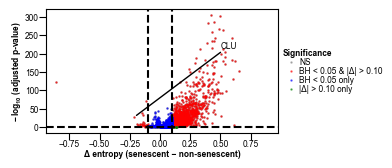

In [34]:
# Volcanoes in the format of the published Fig. 4E panel (06_46c's
# 06_46c_fig5e_volcano_reproducible_only.pdf), via pyVolcano's plot_volcano.
#
# THE THRESHOLDS ARE PINNED HERE, NOT INHERITED. 06_46c's cell 14 uses LFC_THR, PVAL_THR,
# LABEL_LFC and vdf but ASSIGNS NONE OF THEM anywhere in that notebook -- the cell that built
# them was deleted, so it cannot be re-run top to bottom and the panel survives only as a PDF.
# LFC_THR is recovered as 0.1 from 06_46c_final_numbers.csv (`lfc_threshold`), and PVAL_THR as
# 0.05 from the legend text that cell writes. Defining them explicitly is what makes this
# notebook reproducible where 06_46c is not.
#
# THREE pyVolcano GOTCHAS, all handled in the helper:
#   1. it indexes columns by LABEL while iterating POSITIONAL indices, so a boolean-filtered
#      frame with a gapped index raises KeyError -- hence reset_index(drop=True)
#   2. it takes no ax=, calling plt.figure() itself, so each volcano is its own figure and the
#      two cannot be stacked into one subplot grid
#   3. its savefig= bypasses figpath() AND omits bbox_inches, so the save happens outside
from pyVolcano import plot_volcano

LFC_THR = 0.1      # matches Fig. 4E (06_46c_final_numbers.csv: lfc_threshold)
PVAL_THR = 0.05


def volcano_panel(df, fname, xlim, title='', max_labels = 15):
    """One volcano in Fig. 4E's format. `df` needs names / logfoldchanges / pvals_adj."""
    # `xlim` may be a scalar (symmetric, +/-xlim) or an (lo, hi) pair. Asymmetric is the
    # default now: an entropy difference is routinely one-sided, and forcing +/-max wastes
    # half the panel and draws a one-sided effect as though it were centred on zero.
    _lo, _hi = (-float(xlim), float(xlim)) if np.ndim(xlim) == 0 else (float(xlim[0]), float(xlim[1]))
    plot_volcano(
        df,
        lfc_threshold=LFC_THR,
        pval_threshold=PVAL_THR,
        pval_col='pvals_adj',
        logfc_col='logfoldchanges',
        name_col='names',
        xlabel='Δ entropy (senescent − non-senescent)',
        title=title,
        figsize=(3.0, 1.6),
        all_text_size=6,
        point_size=0.5,
        point_alpha=0.6,
        xlims=(_lo, _hi),
        show_gene_labels=True,
        label_lfc_threshold=0.2,
        label_pval_threshold=0.0001,
        max_labels=max_labels,
        return_gene_lists=False,
    )
    # pyVolcano's legend keys are named for a log2-fold-change volcano; this is an entropy
    # difference, so relabel them rather than leave "log2 FC" on a bits axis. Same fix 06_46c
    # applies to Fig. 4E.
    _leg = plt.gca().get_legend()
    if _leg is not None:
        _fix = {'p-value & log2 FC': f'BH < {PVAL_THR} & |Δ| > {LFC_THR:.2f}',
                'p-value': f'BH < {PVAL_THR} only',
                'log2 FC': f'|Δ| > {LFC_THR:.2f} only'}
        for _t in _leg.get_texts():
            if _t.get_text() in _fix:
                _t.set_text(_fix[_t.get_text()])
        _leg.get_title().set_fontweight('bold')
    plt.savefig(figpath(fname), bbox_inches='tight', dpi=300)
    plt.show()


def to_vdf(frame):
    """vol / vol_m -> the column names plot_volcano expects, reproducible genes only."""
    d = pd.DataFrame({'names': frame.gene.values,
                      'logfoldchanges': frame.effect.values,
                      'pvals_adj': frame.padj.values,
                      'reproducible': frame.reproducible.fillna(False).values})
    return d[d.reproducible].reset_index(drop=True)


def _asym_xlim(frame, pad_frac=0.05, fallback=(-1.0, 1.0), include=None):
    # INDEPENDENT negative and positive limits, each fitted to the data actually shown.
    # Returns (lo, hi). Robust to an empty / all-NaN frame, which np.nanmax would turn into
    # a ValueError or a NaN limit that reaches plot_volcano as xlims=(nan, nan).
    v = np.asarray(frame['logfoldchanges'], dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return fallback
    lo, hi = float(v.min()), float(v.max())
    span = (hi - lo) if hi > lo else (abs(hi) if hi else 1.0)
    lo, hi = lo - span * pad_frac, hi + span * pad_frac
    # Zero must stay on the axis: the volcano draws its |effect| thresholds symmetrically
    # about it, and a panel that excludes zero reads as though nothing crossed the origin.
    lo, hi = min(lo, 0.0), max(hi, 0.0)
    if include is not None:      # keep both threshold lines visible even if data is one-sided
        lo, hi = min(lo, float(include[0])), max(hi, float(include[1]))
    return (lo, hi)


vdf_repro = to_vdf(vol)
# Fitted per panel rather than pinned to +/-max: see the note in volcano_panel. `include`
# keeps both +/-LFC_THR threshold lines on the axis when the effects are one-sided.
XLIM_POOLED = _asym_xlim(vdf_repro, include=(-LFC_THR, LFC_THR))
print(f'pooled volcano: {len(vdf_repro):,} donor-reproducible genes of {len(vol):,} testable, '
      f'x = [{XLIM_POOLED[0]:.3f}, {XLIM_POOLED[1]:.3f}]')
volcano_panel(vdf_repro, '06_10_volcano_unconditional.pdf', XLIM_POOLED)

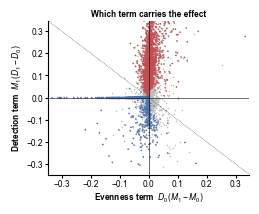

quadrants: points above the dotted anti-diagonal have a positive
unconditional effect. A point in the upper-LEFT quadrant is a gene whose evenness FELL
while its co-detection ROSE -- the H2AZ1 pattern, and the case where calling the result
"increased isoform diversity" depends entirely on the denominator.


In [10]:
# The decomposition, which is what this notebook exists to show. One point per testable gene:
# how much of its unconditional effect is co-detection breadth versus evenness of usage. Points
# far from the diagonal are genes whose "entropy change" is almost entirely a detection change.
d = vol[np.isfinite(vol.term_detection) & np.isfinite(vol.term_evenness)]
lim = float(np.nanpercentile(np.abs(np.r_[d.term_detection, d.term_evenness]), 99.5))

fig, ax = plt.subplots(figsize=(2.6, 2.0))
ax.scatter(d.term_evenness, d.term_detection, s=1.2, c=NS_COLOR, linewidths=0, rasterized=True)
_s = d[d.padj < 0.05]
ax.scatter(_s.term_evenness, _s.term_detection, s=1.2, linewidths=0, rasterized=True,
           c=np.where(_s.effect > 0, UP_COLOR, DOWN_COLOR))
ax.plot([-lim, lim], [lim, -lim], color='k', lw=0.4, ls=':')   # effect = 0 line
ax.axhline(0, color='k', lw=0.4)
ax.axvline(0, color='k', lw=0.4)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('Evenness term  $D_0(M_1-M_0)$')
ax.set_ylabel('Detection term  $M_1(D_1-D_0)$')
ax.set_title('Which term carries the effect', pad=PANEL_TITLE_PAD)

for _sp in ('top', 'right'):
    ax.spines[_sp].set_visible(False)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_10_decomposition.pdf'), bbox_inches='tight', dpi=300)
plt.show()
print('quadrants: points above the dotted anti-diagonal have a positive')
print('unconditional effect. A point in the upper-LEFT quadrant is a gene whose evenness FELL')
print('while its co-detection ROSE -- the H2AZ1 pattern, and the case where calling the result')
print('"increased isoform diversity" depends entirely on the denominator.')

## 8. Depth-matched arm


In [17]:
MATCH_BINS = 20
MATCH_SEED = 0

# ---------------------------------------------------------------- DEPTH MATCHING
# MATCH_WITHIN nests the 1:1 match inside a grouping: the depth quantiles are
# recomputed within each group instead of over the pooled cohort. Set it to None to
# restore the pooled design this section used previously.
#   None      -> pooled over all cells at once
#   'tube_id' -> matched WITHIN SAMPLE: a tube's senescent cells are only ever
#                compared against reference cells drawn from that same tube
MATCH_WITHIN = 'tube_id'

# adata.X is raw counts on the isoform set already filtered to named genes, so this is the
# isoform-level library size -- the same quantity 06_56 matches on.
depth = np.asarray(adata.X.sum(axis=1)).ravel()

_GROUPINGS = {'tube_id': tube.astype(str)}
if 'broad_cell_class' in adata.obs.columns:
    _kl = adata.obs['broad_cell_class'].astype(str).values
    _GROUPINGS['broad_cell_class'] = _kl
    _GROUPINGS['tube_id x broad_cell_class'] = (
        pd.Series(tube.astype(str)).str.cat(pd.Series(_kl), sep='||').values)
if MATCH_WITHIN is None:
    _within, _scheme = None, 'pooled (all cells at once)'
else:
    _within, _scheme = _GROUPINGS[MATCH_WITHIN], MATCH_WITHIN

mi_, mj_ = sr.depth_matched_indices(depth, sen, n_bins=MATCH_BINS, seed=MATCH_SEED,
                                    ratio=1, within=_within)
idx_m = np.sort(np.concatenate([mi_, mj_]))
sen_m = sen[idx_m]
tube_m = tube[idx_m]
donor_m = donor[idx_m]
ns_m, nn_m = int(sen_m.sum()), int((~sen_m).sum())
print(f'depth matching: {_scheme.upper()}'
      + (f'  ({len(pd.unique(_within)):,} groups)' if _within is not None else ''))
print(f'depth-matched subsample: {ns_m:,} senescent + {nn_m:,} reference '
      f'({100 * len(idx_m) / adata.n_obs:.1f}% of all cells)')
print(f'  senescent retained: {ns_m:,}/{int(sen.sum()):,} '
      f'({100 * ns_m / max(int(sen.sum()), 1):.1f}%)')
print(f'  median depth  senescent {np.median(depth[idx_m][sen_m]):,.0f}  '
      f'reference {np.median(depth[idx_m][~sen_m]):,.0f}')
print(f"  Cliff's delta  BEFORE {sr.cliffs_delta(depth[sen], depth[~sen]):+.3f}   "
      f"AFTER {sr.cliffs_delta(depth[idx_m][sen_m], depth[idx_m][~sen_m]):+.3f}")
if ns_m < int(sen.sum()):
    print(f'  NOTE: {int(sen.sum()) - ns_m:,} senescent cells dropped. Either their depth bin')
    print('  held no reference cells, or -- when nesting -- the reference arm was the scarcer')
    print('  one inside a group, so senescent cells were subsampled to match instead.')

# A pooled match balances depth only marginally. Every estimate below blocks on tube,
# so the number that actually matters is the residual gap INSIDE each tube.
_dm = depth[idx_m]
_res, _ok_tubes = [], 0
for _t in pd.unique(tube_m):
    _m = tube_m == _t
    _a2, _b2 = _dm[_m & sen_m], _dm[_m & ~sen_m]
    if _a2.size >= 3 and _b2.size >= 3:
        _res.append(abs(sr.cliffs_delta(_a2, _b2)))
    if _a2.size >= 5 and _b2.size >= 5:
        _ok_tubes += 1
if _res:
    print(f"  residual |Cliff's delta| WITHIN tube: median {np.median(_res):.3f}  "
          f"max {np.max(_res):.3f}  over {len(_res)} tubes with both arms")
print(f'  tubes with >= 5 cells per arm: {_ok_tubes} of {len(np.unique(tube)):,}')

# Permutation labels are rebuilt over the MATCHED cells and shuffled within sample. Subsetting
# a globally shuffled vector would not preserve the subset's arm sizes.
rng_m = np.random.default_rng(MATCH_SEED)
perm_lab_m = np.zeros((N_PERM + 1, len(idx_m)), dtype=bool)
for r in range(N_PERM):
    lab = sen_m.copy()
    for b_ in np.unique(tube_m):
        bi = np.where(tube_m == b_)[0]
        lab[bi] = rng_m.permutation(sen_m[bi])
    perm_lab_m[r] = lab
perm_lab_m[N_PERM] = sen_m

n_expr_m = np.zeros(shape)
n_meas_m = np.zeros(shape)
h_sum_m = np.zeros(shape)
h_sq_m = np.zeros(shape)
pe_m = np.zeros((N_PERM + 1, n_genes))
pn_m = np.zeros((N_PERM + 1, n_genes))
ps_m = np.zeros((N_PERM + 1, n_genes))
pq_m = np.zeros((N_PERM + 1, n_genes))

for start in range(0, len(idx_m), CHUNK):
    end = min(start + CHUNK, len(idx_m))
    rows_ = idx_m[start:end]
    b = frac[rows_]
    term = b.copy()
    term.data = -term.data * np.log2(np.maximum(term.data, 1e-300))
    H = np.asarray((term @ iso_to_gene).todense(), dtype=np.float64)
    nexp = np.asarray(((b > 0).astype(np.float32) @ iso_to_gene).todense())
    expr = nexp >= 1
    meas = nexp >= 2
    Hh = np.where(expr, H, 0.0)
    sn = sen_m[start:end]
    for a in (0, 1):
        m_ = sn == bool(a)
        if not m_.any():
            continue
        n_expr_m[a] += expr[m_].sum(axis=0)
        n_meas_m[a] += meas[m_].sum(axis=0)
        h_sum_m[a] += Hh[m_].sum(axis=0)
        h_sq_m[a] += (Hh[m_] ** 2).sum(axis=0)
    Pm = perm_lab_m[:, start:end].astype(np.float64)
    pe_m += Pm @ expr.astype(np.float64)
    pn_m += Pm @ meas.astype(np.float64)
    ps_m += Pm @ Hh
    pq_m += Pm @ (Hh ** 2)
    del b, term, H, nexp, expr, meas, Hh, Pm
    gc.collect()
    print(f'  {end:,}/{len(idx_m):,}', flush=True)

for _nm, _p, _o in (('expr', pe_m, n_expr_m), ('meas', pn_m, n_meas_m),
                    ('sum', ps_m, h_sum_m), ('sq', pq_m, h_sq_m)):
    _sc = max(1.0, float(np.abs(_o).max()))
    _r1 = float(np.abs(_p[N_PERM] - _o[1]).max()) / _sc
    _r0 = float(np.abs((_o.sum(axis=0) - _p[N_PERM]) - _o[0]).max()) / _sc
    assert _r1 < 1e-9 and _r0 < 1e-9, f'matched permutation self-check failed on {_nm}'
print('  matched self-check OK')
pe_m, pn_m, ps_m, pq_m = pe_m[:N_PERM], pn_m[:N_PERM], ps_m[:N_PERM], pq_m[:N_PERM]

DENOM_m = n_expr_m if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else n_meas_m
eff_m, se_m, testable_m = effect_from_accumulators(DENOM_m, h_sum_m, h_sq_m)
padj_m = sr.bh(2 * stats.norm.sf(np.abs(eff_m / se_m)))

with np.errstate(invalid='ignore', divide='ignore'):
    D_m = n_meas_m / n_expr_m
    M_m = np.where(n_meas_m > 0, h_sum_m / np.maximum(n_meas_m, 1), 0.0)
det_m = M_m[1] * (D_m[1] - D_m[0])
even_m = D_m[0] * (M_m[1] - M_m[0])

tot_e_m, tot_n_m = n_expr_m.sum(axis=0), n_meas_m.sum(axis=0)
tot_s_m, tot_q_m = h_sum_m.sum(axis=0), h_sq_m.sum(axis=0)
null_m = []
for r in range(N_PERM):
    dn_ = pe_m[r] if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else pn_m[r]
    tt_ = tot_e_m if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else tot_n_m
    e_r, _, ok_r = effect_from_accumulators(np.stack([tt_ - dn_, dn_]),
                                            np.stack([tot_s_m - ps_m[r], ps_m[r]]),
                                            np.stack([tot_q_m - pq_m[r], pq_m[r]]))
    if ok_r.sum():
        null_m.append(100 * np.mean(e_r[ok_r] > 0))
null_m = np.array(null_m)
obs_m = 100 * float(np.mean(eff_m[testable_m] > 0))
z_null_m = (obs_m - null_m.mean()) / null_m.std() if null_m.std() > 0 else np.nan
print()
print(f'MATCHED: {int(testable_m.sum()):,} testable genes   increased {obs_m:.1f}%   '
      f'null {null_m.mean():.1f}% +/- {null_m.std():.1f}%   z {z_null_m:+.2f}')
print(f'  co-detection D  senescent {np.nanmedian(D_m[1][testable_m]):.4f}  '
      f'non-senescent {np.nanmedian(D_m[0][testable_m]):.4f}  '
      f'ratio {np.nanmedian(D_m[1][testable_m]) / max(np.nanmedian(D_m[0][testable_m]), 1e-12):.2f}x')
print(f'  (pooled was {final["pct_increased"]:.1f}% of {final["n_testable_genes"]:,}, '
      f'null {final["null_pct_mean"]:.1f}%, z {final["null_z"]:+.2f}, D ratio '
      f'{final["median_D_sen"] / max(final["median_D_non"], 1e-12):.2f}x)')
print()
print('The D ratio is the check that matching removed what it was meant to. If it is still near')
print('the pooled value, matching failed and nothing below should be read as depth-controlled.')
final['matched_n_testable'] = int(testable_m.sum())
final['matched_pct_increased'] = obs_m
final['matched_null_pct_mean'] = float(null_m.mean())
final['matched_null_z'] = float(z_null_m)
final['matched_n_sen_cells'] = ns_m
final['matched_n_ref_cells'] = nn_m
final['matched_median_D_sen'] = float(np.nanmedian(D_m[1][testable_m]))
final['matched_median_D_non'] = float(np.nanmedian(D_m[0][testable_m]))


depth matching: TUBE_ID  (50 groups)
depth-matched subsample: 3,134 senescent + 2,963 reference (4.0% of all cells)
  senescent retained: 3,134/3,134 (100.0%)
  median depth  senescent 3,680  reference 3,460
  Cliff's delta  BEFORE +0.449   AFTER +0.046
  residual |Cliff's delta| WITHIN tube: median 0.040  max 0.778  over 40 tubes with both arms
  tubes with >= 5 cells per arm: 36 of 50
  4,000/6,097
  6,097/6,097
  matched self-check OK

MATCHED: 14,236 testable genes   increased 59.3%   null 48.7% +/- 3.3%   z +3.25
  co-detection D  senescent 0.0843  non-senescent 0.0735  ratio 1.15x
  (pooled was 71.4% of 16,293, null 47.3%, z +16.01, D ratio 1.90x)

The D ratio is the check that matching removed what it was meant to. If it is still near
the pooled value, matching failed and nothing below should be read as depth-controlled.


  TSP21: 6,967 genes estimable (matched)
  TSP25: 10,216 genes estimable (matched)
  TSP27: 8,417 genes estimable (matched)
  TSP33: 10,896 genes estimable (matched)

wrote 06_10_volcano_depth_matched.csv (14,236 rows)

genes testable in BOTH arms: 14,236
  Spearman(pooled, matched) = +0.571
  sign flips 27.6%   median |effect| x0.78 vs pooled
  BH < 0.05: pooled 6,376  matched 2,224  both 1,911
  A low Spearman with ~50% sign flips means per-gene calls do not survive the depth
  control, whatever the aggregate does -- read the headline, not the gene list.
x limits: pooled [-0.945, 0.978]   matched [-0.501, 0.418]
  a shared axis would compress the matched panel 2.1x
matched volcano: 4,458 donor-reproducible genes of 14,236 testable, x = [-0.501, 0.418]
[pyVolcano] labelling 15 of 76 significant points (max_labels=15)


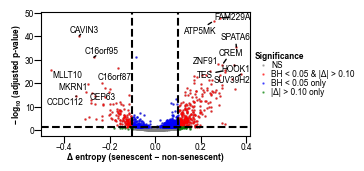

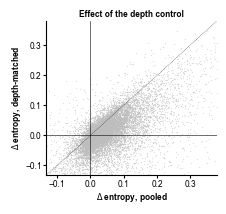

In [18]:
# Cross-donor reproducibility on the matched subsample, same rule as section 6 so the two
# volcanoes are filtered identically. min_cells is 10 per arm per donor, as there.
donor_eff_m = np.full((len(donors), n_genes), np.nan)
for di, dn in enumerate(donors):
    dm = donor_m == dn
    if not dm.any():
        continue
    ne_ = np.zeros(shape); nm_ = np.zeros(shape)
    ss_ = np.zeros(shape); sq_ = np.zeros(shape)
    sub_idx = idx_m[dm]
    sen_d = sen_m[dm]
    for start in range(0, len(sub_idx), CHUNK):
        end = min(start + CHUNK, len(sub_idx))
        b = frac[sub_idx[start:end]]
        term = b.copy()
        term.data = -term.data * np.log2(np.maximum(term.data, 1e-300))
        H = np.asarray((term @ iso_to_gene).todense(), dtype=np.float64)
        nexp = np.asarray(((b > 0).astype(np.float32) @ iso_to_gene).todense())
        expr = nexp >= 1
        meas = nexp >= 2
        Hh = np.where(expr, H, 0.0)
        sn = sen_d[start:end]
        for a in (0, 1):
            m_ = sn == bool(a)
            if not m_.any():
                continue
            ne_[a] += expr[m_].sum(axis=0)
            nm_[a] += meas[m_].sum(axis=0)
            ss_[a] += Hh[m_].sum(axis=0)
            sq_[a] += (Hh[m_] ** 2).sum(axis=0)
        del b, term, H, nexp, expr, meas, Hh
    dn_arr = ne_ if MIN_ISOFORMS_FOR_DENOMINATOR == 1 else nm_
    e_d, _, ok_d = effect_from_accumulators(dn_arr, ss_, sq_, min_cells=MIN_CELLS_PER_ARM_DONOR)
    donor_eff_m[di] = np.where(ok_d, e_d, np.nan)
    print(f'  {dn}: {int(np.isfinite(donor_eff_m[di]).sum()):,} genes estimable (matched)')
    gc.collect()

sp_m = np.nansum(donor_eff_m > 0, axis=0)
sn_m_ = np.nansum(donor_eff_m < 0, axis=0)
nd_m = np.sum(np.isfinite(donor_eff_m), axis=0)
repro_m = (((sp_m >= MIN_DONORS_CONCORDANT) | (sn_m_ >= MIN_DONORS_CONCORDANT))
           & (nd_m >= MIN_DONORS_ESTIMABLE))

vol_m = pd.DataFrame({
    'gene': genes, 'effect': eff_m, 'se': se_m, 'padj': padj_m,
    'n_expr_sen': n_expr_m[1], 'n_expr_non': n_expr_m[0],
    'D_sen': D_m[1], 'D_non': D_m[0],
    'term_detection': det_m, 'term_evenness': even_m,
    'n_donors': nd_m, 'n_donors_pos': sp_m, 'reproducible': repro_m,
})[testable_m].copy()
vol_m.to_csv(OUT + '/06_10_volcano_depth_matched.csv', index=False)
print(f'\nwrote 06_10_volcano_depth_matched.csv ({len(vol_m):,} rows)')

cmp_ = vol.merge(vol_m[['gene', 'effect', 'padj']], on='gene', how='inner',
                 suffixes=('_pooled', '_matched'))
_f = np.isfinite(cmp_.effect_pooled) & np.isfinite(cmp_.effect_matched)
_flip = np.sign(cmp_.effect_pooled[_f]) != np.sign(cmp_.effect_matched[_f])
print()
print(f'genes testable in BOTH arms: {int(_f.sum()):,}')
print(f'  Spearman(pooled, matched) = '
      f'{cmp_.effect_pooled[_f].corr(cmp_.effect_matched[_f], method="spearman"):+.3f}')
print(f'  sign flips {100 * _flip.mean():.1f}%   '
      f'median |effect| x{np.median(np.abs(cmp_.effect_matched[_f])) / max(np.median(np.abs(cmp_.effect_pooled[_f])), 1e-12):.2f} vs pooled')
print(f'  BH < 0.05: pooled {int((cmp_.padj_pooled < 0.05).sum()):,}  '
      f'matched {int((cmp_.padj_matched < 0.05).sum()):,}  '
      f'both {int(((cmp_.padj_pooled < 0.05) & (cmp_.padj_matched < 0.05)).sum()):,}')
print('  A low Spearman with ~50% sign flips means per-gene calls do not survive the depth')
print('  control, whatever the aggregate does -- read the headline, not the gene list.')

# --- matched volcano, same Fig. 4E format as the pooled one ------------------------------
# plot_volcano takes no ax=, so this cannot share a subplot grid with the scatter below; the
# two are separate figures by necessity, not by choice.
vdf_m_repro = to_vdf(vol_m)

# X LIMITS, fitted per panel and ASYMMETRIC. Depth matching discards most of the reference
# arm, so the matched effects are generally smaller than the pooled ones; pinning both panels
# to a shared +/-max drew the matched points squeezed into the middle of an axis scaled by a
# different dataset, which reads as "the effect vanished" when it is only the axis.
#
# Negative and positive limits are set independently by _asym_xlim (defined with the volcano
# helpers above), because an entropy difference is routinely one-sided. Set SHARE_VOLCANO_XLIM
# to True to put both panels on one axis instead -- correct only when they are placed side by
# side and read as a single comparison. The widths printed below say what that would cost.
SHARE_VOLCANO_XLIM = False

XLIM_MATCHED = _asym_xlim(vdf_m_repro, fallback=XLIM_POOLED, include=(-LFC_THR, LFC_THR))
_w_pool = XLIM_POOLED[1] - XLIM_POOLED[0]
_w_match = XLIM_MATCHED[1] - XLIM_MATCHED[0]
print(f'x limits: pooled [{XLIM_POOLED[0]:.3f}, {XLIM_POOLED[1]:.3f}]   '
      f'matched [{XLIM_MATCHED[0]:.3f}, {XLIM_MATCHED[1]:.3f}]')
print(f'  a shared axis would compress the matched panel '
      f'{_w_pool / max(_w_match, 1e-12):.1f}x')
if len(vdf_m_repro) == 0:
    print('  WARNING: no donor-reproducible genes in the matched arm -- the volcano below is')
    print('  empty and its axis is the pooled fallback, not a fitted limit.')

if SHARE_VOLCANO_XLIM:
    XLIM_MATCHED = (min(XLIM_POOLED[0], XLIM_MATCHED[0]), max(XLIM_POOLED[1], XLIM_MATCHED[1]))
    if XLIM_MATCHED != XLIM_POOLED:
        # the union reaches past the pooled panel's own axis: redraw it so the pair matches
        print(f'  shared axis: redrawing BOTH panels at '
              f'[{XLIM_MATCHED[0]:.3f}, {XLIM_MATCHED[1]:.3f}]')
        volcano_panel(vdf_repro, '06_10_volcano_unconditional.pdf', XLIM_MATCHED)
# When not sharing, the pooled panel keeps the limit cell[16] gave it and is NOT re-saved here,
# so running this cell no longer silently overwrites 06_10_volcano_unconditional.pdf at a
# different scale than the one cell[16] printed.

print(f'matched volcano: {len(vdf_m_repro):,} donor-reproducible genes of {len(vol_m):,} '
      f'testable, x = [{XLIM_MATCHED[0]:.3f}, {XLIM_MATCHED[1]:.3f}]')
# LABEL THRESHOLD. volcano_panel pins label_lfc_threshold=0.2 to match Fig. 4E. If the matched
# effects do not reach 0.2 no gene is labelled -- that is the panel telling the truth about the
# effect size, not a plotting fault, but it is worth knowing before reading an unlabelled panel.
if max(abs(XLIM_MATCHED[0]), abs(XLIM_MATCHED[1])) < 0.2:
    print('  NOTE: every matched effect is below the 0.2 label threshold, so no gene will be')
    print('  labelled in this panel.')
volcano_panel(vdf_m_repro, '06_10_volcano_depth_matched.pdf', XLIM_MATCHED)

# --- pooled vs matched effect per gene, a plain scatter (not a volcano) -----------------
fig, ax = plt.subplots(figsize=(2.2, 2.0))
ax.scatter(cmp_.effect_pooled[_f], cmp_.effect_matched[_f], s=0.8, linewidths=0,
           rasterized=True, alpha=0.5, color=NS_COLOR)
_lo, _hi = np.nanpercentile(cmp_.effect_pooled[_f], [1, 99])
ax.plot([_lo, _hi], [_lo, _hi], color='k', lw=0.4, ls=':')
ax.axhline(0, color='k', lw=0.4)
ax.axvline(0, color='k', lw=0.4)
ax.set_xlim(_lo, _hi); ax.set_ylim(_lo, _hi)
ax.set_xlabel('$\\Delta$ entropy, pooled')
ax.set_ylabel('$\\Delta$ entropy, depth-matched')
ax.set_title('Effect of the depth control', pad=PANEL_TITLE_PAD)
for _sp in ('top', 'right'):
    ax.spines[_sp].set_visible(False)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_10_pooled_vs_matched_effect.pdf'), bbox_inches='tight', dpi=300)
plt.show()
final['matched_n_reproducible'] = int(vol_m.reproducible.fillna(False).sum())
final['matched_sign_flip_pct_vs_pooled'] = float(100 * _flip.mean())

In [21]:
XLIM_MATCHED

(-0.501268650599206, 0.417975003740504)

[pyVolcano] labelling 20 of 76 significant points (max_labels=20)


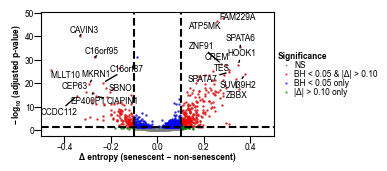

In [35]:
volcano_panel(vdf_m_repro, '06_10_volcano_depth_matched.pdf', (-0.50, 0.50), max_labels=20)

## 8b. Fig. 4F -- per-cell isoform composition for one gene, on the matched arm


Fig. 4F panel on 6,097 depth-matched cells (3,134 senescent, 2,963 reference)
Gene TES (TES) | 10 isoforms | FULL DATASET, all cell types
  cells expressing the gene : 520 non / 1,042 sen
  cells with >=2 isoforms   : 520 non / 1,042 sen

censoring (entropy undefined at 1 isoform):
  non: 0/520 = 0.0% of expressing cells dropped
  sen: 0/1,042 = 0.0% of expressing cells dropped
  arms differ by +0.0 points -- if senescent cells are
  censored MORE, collapses to single-isoform usage are being removed from their own arm.

depth (library size of entropy-defined cells):
  median 6,983 sen vs 5,816 non (1.20x), Cliff's delta +0.157
  per-cell entropy rises with depth, so the gap below is depth-inflated. NOT corrected here.

cell-class composition among entropy-defined cells, top 5 |sen - non|:
                                 sen     non    diff
male germ cell                 63.6%   42.3%   21.3%
transitional epithelial cell    3.2%    6.2%   -3.0%
lymphocyte of b lineage        11.7%   14

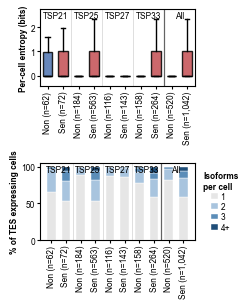

In [33]:
# === Fig. 4F, regenerated on THIS notebook's arm =========================================
# Ported verbatim from 06_10b cell 33 (the cell that produced the published
# 06_03_selected_gene_isoform_composition_alltypes.pdf), then rewired -- the same approach
# 06_47c used for its per-gene panels.
#
# WHAT DIFFERS FROM THE PUBLISHED PANEL, and it is the whole point of regenerating it:
#   * cells        -- the 1:1 DEPTH-MATCHED subsample `idx_m` from section 8, not all cells
#   * denominator  -- unconditional throughout this notebook; the right panel already counted
#                     every expressing cell, so only the left (entropy) panel changes set
#   * ISO_PANEL    -- forced to "composition". 06_10b currently sets "box", which writes a
#                     BOXPLOT into a file named ..._isoform_composition_...pdf. Fig. 4F's
#                     legend describes a composition panel, so that is what this produces.
#
# NEW BASENAMES (06_10_selected_gene_*): the published file is still Fig. 4F in the panel map,
# and writing this figure to that name would silently replace a mapped panel before anyone has
# compared them. Repoint Fig. 4F once you have.
#
# The shim below is the only wiring; everything after it is 06_10b's code unchanged.
_A            = adata[idx_m]          # depth-matched view; every .obs lookup inherits it
frac_mat      = frac[idx_m]
sen_mask      = sen[idx_m]
non_mask      = ~sen_mask
unique_genes  = genes                 # 06_10's `genes` holds SYMBOLS, so no ENSG map is needed
ensg_to_name  = {}                    # .get(sym, sym) then returns the symbol unchanged
mannwhitneyu  = stats.mannwhitneyu
print(f'Fig. 4F panel on {len(idx_m):,} depth-matched cells '
      f'({int(sen_mask.sum()):,} senescent, {int(non_mask.sum()):,} reference)')

# Per-cell isoform-diversity DISTRIBUTION for ONE gene across the FULL DATASET (all cell types),
# senescent vs non-senescent. Same two panels as the cell above with the cell-type restriction
# removed: per-donor pairs, plus a pooled "All" pair.
#
# READ THE DIAGNOSTICS PRINTED BELOW BEFORE QUOTING ANYTHING FROM THIS PANEL. Pooling over cell
# types drops the composition control the per-cell-type version had, and nothing here is
# depth-corrected (06_06 / 06_07).
#
# NOTE THE TWO PANELS DESCRIBE DIFFERENT CELL SETS, which is why they carry separate n's:
#   left  (entropy)  -- only cells with >= 2 isoforms of the gene; entropy is undefined at 1
#   right (isoform count) -- every cell expressing the gene, including the 1-isoform cells
# A donor can therefore clear the keep test on a handful of >=2-isoform cells while its
# right-hand box sits flat at 1. Such donors are listed in the audit below and either flagged
# red or removed from the figure, per DEGENERATE_ACTION.
SELECTED_GENE = "TES"       # symbol or ENSG present in adata.var
# MIN_CELLS_PER_GROUP / MIN_EXPR_CELLS_PER_GROUP now come from the config cell.
# --- DONOR GATE ---------------------------------------------------------------------------
# 06_10b gates a donor on cells with >= 2 ISOFORMS, because it was written for the CONDITIONAL
# estimand where those are the only cells that contribute. This notebook is UNCONDITIONAL and
# its volcano gates a donor on cells EXPRESSING the gene (>= 1 isoform, min_cells=10). Roughly
# 90% of (cell, gene) pairs hold exactly one isoform, so the two gates disagree hard: a gene can
# clear the volcano in all four donors and still show only two here.
#   'match_volcano'   -- gate on expressing cells, so the panel shows the donors the volcano
#                        actually used. Correct for the composition panel, which plots the
#                        1-isoform cells too.
#   'entropy_defined' -- 06_10b's original gate. Correct if you only care about the LEFT
#                        (entropy) panel, which genuinely needs >= 2 isoforms.
# DONOR GATE, shared rule with 06_11. A donor is drawn only if it BOTH
#   (a) contributed to the test -- >= MIN_EXPR_CELLS_PER_GROUP cells EXPRESSING the gene
#       per arm, the same population the estimator's denominator counts, and
#   (b) is drawable -- >= MIN_CELLS_PER_GROUP cells with >= 2 isoforms per arm, since the
#       boxes plot an entropy distribution and a 1-isoform cell is a point mass at 0.
# Either test alone is defensible but they answer different questions, and the two
# notebooks used to apply a different one each, so a donor could appear in one panel and
# not the other. 'both' is the conjunction; the single-criterion options are kept so the
# old behaviour is reproducible.
# The >=2-isoform ARM FILTER is off: the gate is the EXPRESSING count only, the same
# population the estimator's denominator uses.
DONOR_GATE = 'match_volcano'
SHOW_POOLED = True            # append an "All donors" pair on the right
SINGLE_ISO_WARN = 0.99       # a donor is "degenerate" if >= this fraction of its expressing cells have 1 iso
ISO_PANEL = "composition"     # right panel: "composition" -> stacked % of expressing cells by
                              # isoform count (default) | "box" -> the old boxplot
ISO_KMAX = 4                  # composition bins: 1, 2, ..., ISO_KMAX-1, then ISO_KMAX+
SAVE_PANELS_SEPARATELY = False # also write each panel as its own PDF (the panel map points at
                              # whole FILES, so a panel that stands alone needs its own file)
DEGENERATE_ACTION = "flag"    # "flag" -> keep it with red labels | "drop" -> remove it from the figure
                              # FLAG, not drop: under the unconditional gate a donor whose cells
                              # are almost all single-isoform is a real observation about this
                              # gene, not a defective donor, and dropping it silently removes a
                              # donor the volcano counted.

# resolve gene to the ENSG-ish value held in unique_genes
if SELECTED_GENE in unique_genes:
    _gene = SELECTED_GENE; _label = ensg_to_name.get(SELECTED_GENE, SELECTED_GENE)
else:
    _n2e = {v: k for k, v in ensg_to_name.items()}
    if SELECTED_GENE in _n2e:
        _gene, _label = _n2e[SELECTED_GENE], SELECTED_GENE
    else:
        raise ValueError(f"{SELECTED_GENE} not found (try a symbol or ENSG present in adata.var)")
g_idx = int(np.where(unique_genes == _gene)[0][0])
iso_idx = np.where(gene_of_iso == g_idx)[0]

# this gene's isoform fractions -> per-cell entropy + per-cell #expressed isoforms, ALL cells
GF = np.asarray(frac_mat[:, iso_idx].todense()) if issparse(frac_mat) else np.asarray(frac_mat[:, iso_idx])
nz = GF > 0
n_iso_cell = nz.sum(axis=1)
with np.errstate(divide="ignore", invalid="ignore"):
    term = np.where(nz, -GF * np.log2(np.maximum(GF, 1e-300)), 0.0)
ent_cell = np.where(n_iso_cell >= 1, term.sum(axis=1), np.nan)   # defined only for >=1 isoforms
expressed = GF.sum(axis=1) > 0
defined = ~np.isnan(ent_cell)

donor_arr = _A.obs["donor"].astype(str).values
donors_all = sorted(pd.unique(donor_arr))


def _cliffs_delta(a, b):
    """P(a>b) - P(a<b), from the MW U statistic. Effect size only, deliberately no p-value."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    if len(a) == 0 or len(b) == 0:
        return np.nan
    u = mannwhitneyu(a, b, alternative="two-sided").statistic
    return 2.0 * u / (len(a) * len(b)) - 1.0


print(f"Gene {_label} ({_gene}) | {len(iso_idx)} isoforms | FULL DATASET, all cell types")
print(f"  cells expressing the gene : {int((expressed & non_mask).sum()):,} non / "
      f"{int((expressed & sen_mask).sum()):,} sen")
print(f"  cells with >=2 isoforms   : {int((defined & non_mask).sum()):,} non / "
      f"{int((defined & sen_mask).sum()):,} sen")

# --- Diagnostic 1: censoring -------------------------------------------------------------
# Entropy is undefined at exactly 1 detected isoform, so a cell whose usage COLLAPSES to a
# single isoform is dropped rather than scored 0. Decreases are censored, increases are not.
print("\ncensoring (entropy undefined at 1 isoform):")
_cens = {}
for _lab, _m in [("non", non_mask), ("sen", sen_mask)]:
    _e = int((expressed & _m).sum()); _d = int((defined & _m).sum())
    _cens[_lab] = (_e - _d) / _e if _e else np.nan
    print(f"  {_lab}: {_e - _d:,}/{_e:,} = {_cens[_lab]:.1%} of expressing cells dropped")
print(f"  arms differ by {100 * (_cens['sen'] - _cens['non']):+.1f} points -- if senescent cells are")
print("  censored MORE, collapses to single-isoform usage are being removed from their own arm.")

# --- Diagnostic 2: depth -----------------------------------------------------------------
if "total_counts" in adata.obs.columns:
    _dc = _A.obs["total_counts"].values.astype(float)
    _ds, _dn = _dc[defined & sen_mask], _dc[defined & non_mask]
    if len(_ds) and len(_dn):
        print("\ndepth (library size of entropy-defined cells):")
        print(f"  median {np.median(_ds):,.0f} sen vs {np.median(_dn):,.0f} non "
              f"({np.median(_ds) / np.median(_dn):.2f}x), Cliff's delta {_cliffs_delta(_ds, _dn):+.3f}")
        print("  per-cell entropy rises with depth, so the gap below is depth-inflated. NOT corrected here.")
else:
    print("\ndepth: 'total_counts' absent from adata.obs -- depth diagnostic skipped.")

# --- Diagnostic 3: composition -----------------------------------------------------------
# Pooling over cell types means the contrast also carries the difference in cell-type makeup
# between the arms; a pooled shift can be composition rather than a within-type change.
if "broad_cell_class" in adata.obs.columns:
    _bcc = _A.obs["broad_cell_class"].astype(str).values
    _comp = pd.DataFrame({
        "sen": pd.Series(_bcc[defined & sen_mask]).value_counts(normalize=True),
        "non": pd.Series(_bcc[defined & non_mask]).value_counts(normalize=True),
    }).fillna(0.0)
    _comp["diff"] = _comp["sen"] - _comp["non"]
    print("\ncell-class composition among entropy-defined cells, top 5 |sen - non|:")
    print(_comp.reindex(_comp["diff"].abs().sort_values(ascending=False).index).head(5)
          .to_string(float_format=lambda v: f"{v:7.1%}"))

# --- per-donor audit, printed BEFORE the keep test ---------------------------------------
# expr = cells expressing the gene; one = of those, cells with exactly 1 isoform (entropy
# undefined, dropped from the left panel but PRESENT in the right); def = cells with >= 2.
_rows = []
for _d in donors_all:
    _dm = donor_arr == _d
    _r = {"donor": _d}
    for _lab, _m in [("non", non_mask), ("sen", sen_mask)]:
        _s = _dm & _m
        _r[f"expr_{_lab}"] = int((_s & expressed).sum())
        _r[f"one_{_lab}"] = int((_s & expressed & ~defined).sum())
        _r[f"def_{_lab}"] = int((_s & defined).sum())
    _rows.append(_r)
audit = pd.DataFrame(_rows).set_index("donor")

# Hard floor of 1: a donor in which entropy is definable in NO cell can never be plotted,
# whatever MIN_CELLS_PER_GROUP is set to. Without this, MIN_CELLS_PER_GROUP = 0 makes the
# keep test vacuous (0 >= 0) and admits donors whose every cell has a single isoform.
_MIN_DEF = max(1, int(MIN_CELLS_PER_GROUP))
if MIN_CELLS_PER_GROUP < 1:
    print(f"\nNOTE: MIN_CELLS_PER_GROUP={MIN_CELLS_PER_GROUP} would admit donors with no cell in which")
    print(f"      entropy is definable; the keep test uses a floor of {_MIN_DEF}.")
_g = int(MIN_EXPR_CELLS_PER_GROUP)
_expr_ok = (audit["expr_non"] >= _g) & (audit["expr_sen"] >= _g)
_def_ok = (audit["def_non"] >= _MIN_DEF) & (audit["def_sen"] >= _MIN_DEF)
if DONOR_GATE == 'both':
    audit["kept"] = _expr_ok & _def_ok
    print(f'\ndonor gate: EXPRESSING >= {_g} AND >=2-isoform >= {_MIN_DEF}, per arm')
elif DONOR_GATE == 'match_volcano':
    # PLOTTABILITY FLOOR, not a filter. A donor with zero cells in which entropy is
    # DEFINED contributes an empty dataset to ax.boxplot, which raises
    # "List of boxplot statistics and `positions` values must have same the length".
    # >= 1 is the minimum that can be drawn at all; it is not a power threshold.
    _plot_ok = (audit["def_non"] >= 1) & (audit["def_sen"] >= 1)
    audit["kept"] = _expr_ok & _plot_ok
    print(f'\ndonor gate: EXPRESSING cells >= {_g} per arm (matches the volcano);'
          f' >=2-isoform filter REMOVED, floor of 1 kept only so the box can draw')
    print(f'  donors excluded by the drawability floor alone: '
          f'{int((_expr_ok & ~_plot_ok).sum())}')
elif DONOR_GATE == 'entropy_defined':
    audit["kept"] = _def_ok
    print(f'\ndonor gate: cells with >=2 isoforms >= {_MIN_DEF} per arm (06_10b original)')
else:
    raise ValueError(f"DONOR_GATE must be 'both', 'match_volcano' or "
                     f"'entropy_defined', got {DONOR_GATE!r}")
print(f'  dropped by the EXPRESSING test only : {int((~_expr_ok & _def_ok).sum())}')
print(f'  dropped by the >=2-isoform test only: {int((_expr_ok & ~_def_ok).sum())}')

# donors whose expressing cells are almost all single-isoform: they may clear the keep test
# on a handful of atypical cells while the right panel is pinned at 1
_expr_tot = (audit["expr_non"] + audit["expr_sen"]).replace(0, np.nan)
audit["frac_1iso"] = (audit["one_non"] + audit["one_sen"]) / _expr_tot
audit["degenerate"] = audit["kept"] & (audit["frac_1iso"] >= SINGLE_ISO_WARN)

if DEGENERATE_ACTION not in ("flag", "drop"):
    raise ValueError(f"DEGENERATE_ACTION must be 'flag' or 'drop', got {DEGENERATE_ACTION!r}")
if DEGENERATE_ACTION == "drop":
    audit["shown"] = audit["kept"] & ~audit["degenerate"]
    dropped_degenerate = audit.index[audit["degenerate"]].tolist()
    degenerate = []                      # nothing left on the figure to flag
else:
    audit["shown"] = audit["kept"]
    dropped_degenerate = []
    degenerate = audit.index[audit["degenerate"]].tolist()

print(f"\nper-donor audit for {_label} (expr = expressing, one = exactly 1 isoform, def = >=2):")
print(audit.to_string(float_format=lambda v: f"{v:.3f}"))
groups = audit.index[audit["shown"]].tolist()

# RECONCILIATION against the volcano. donor_eff_m (section 8) holds the per-donor effect on the
# matched cells, so a finite entry is exactly "this donor was estimable for this gene" by the
# volcano's own rule. If the two disagree, the panel is not showing what the volcano counted.
try:
    _vol_donors = [d for d, ok in zip(donors, np.isfinite(donor_eff_m[:, g_idx])) if ok]
except Exception:
    _vol_donors = None
if _vol_donors is not None:
    print(f'\nvolcano used {len(_vol_donors)} donor(s) for {_label}: {_vol_donors}')
    print(f'panel shows  {len(groups)} donor(s): {groups}')
    _missing = [d for d in _vol_donors if d not in groups]
    if _missing:
        print(f'  !! {len(_missing)} donor(s) the volcano counted are NOT on this panel: {_missing}')
        print('     With DONOR_GATE=\'match_volcano\' this should not happen for the count test;')
        print('     if it does, they were removed as degenerate (DEGENERATE_ACTION) or hold too')
        print('     few cells after depth matching. The audit table above says which.')
print(f"\nDonors passing the count test (>= {_MIN_DEF} cells with >=2 iso in BOTH arms): "
      f"{int(audit['kept'].sum())} of {len(donors_all)}")
print(f"Donors plotted: {len(groups)} -> {groups}")
_why = (f">= {SINGLE_ISO_WARN:.0%} of their expressing cells hold a single isoform, so their\n"
        "  left-panel entropy rests on a small, atypical subset while the right panel is pinned at 1")
if dropped_degenerate:
    print(f"REMOVED (DEGENERATE_ACTION='drop'): {dropped_degenerate}\n  {_why}.")
if degenerate:
    print(f"FLAGGED RED (DEGENERATE_ACTION='flag'): {degenerate}\n  {_why}.")
    print("  Do not read these as a diversity difference.")

_specs = [(d, donor_arr == d) for d in groups]
if SHOW_POOLED:
    _specs.append(("All", np.ones(len(donor_arr), bool)))
    if len(groups) < len(donors_all):
        print(f"\n'All' pools EVERY cell, including the {len(donors_all) - len(groups)} donor(s) not shown;")
        print("  it is not the sum of the donor pairs to its left.")

# --- build the boxes ---------------------------------------------------------------------
# Separate labels per panel: the two panels are computed on different cell sets, so one
# shared "n=" would misreport whichever panel it was not taken from.
ent_data, iso_data, ent_labels, iso_labels, grp, pair_names, flag = [], [], [], [], [], [], []
_pct2 = []
for _name, _dm in _specs:
    for _glab, _gm in [("Non", non_mask), ("Sen", sen_mask)]:
        _sel = _gm & _dm
        _e = ent_cell[_sel]; _e = _e[~np.isnan(_e)]
        _k = n_iso_cell[_sel & expressed]
        # The right panel's box can sit flat at 1 while the left panel is populated: entropy
        # is computed on exactly the cells that box HIDES. showfliers=False suppresses the
        # >=2-isoform tail, so a gene where 90% of cells hold one isoform looks like a gene
        # with no diversity at all. Carry the >=2 percentage in the tick label so the link
        # between the two panels is on the figure rather than inferred.
        _p2 = 100 * float((_k >= 2).sum()) / max(len(_k), 1)
        ent_data.append(_e); iso_data.append(_k); _pct2.append(_p2)
        ent_labels.append(f"{_glab} (n={len(_e):,})")
        # iso_labels.append(f"{_glab} (n={len(_k):,}; {_p2:.0f}% >=2 iso)")
        iso_labels.append(f"{_glab} (n={len(_k):,})")
        grp.append(_glab); flag.append(_name in degenerate)
    pair_names.append(_name)
colors = ["#4c72b0" if g == "Non" else "#c44e52" for g in grp]

# --- effect sizes ------------------------------------------------------------------------
# Cliff's delta only. A pooled Mann-Whitney over ~150k cells would treat cells as replicates;
# the donor rows are the replicate-level read, and the sign count across them is the claim.
# The two panels are computed on DIFFERENT cell sets and their n's are not expected to
# agree: the left uses cells with >=2 isoforms of the gene (entropy is undefined below that),
# the right uses every expressing cell. The first is a strict subset of the second.
print("\ncells behind each panel (NOT the same set):")
print(f"  {'group':>10s} {'arm':>4s} {'expressing':>11s} {'>=2 iso':>9s} {'% >=2':>7s}")
for _j, _name in enumerate(pair_names):
    for _o, _arm in ((0, "Non"), (1, "Sen")):
        _i2 = 2 * _j + _o
        print(f"  {_name:>10s} {_arm:>4s} {len(iso_data[_i2]):11,d} "
              f"{len(ent_data[_i2]):9,d} {_pct2[_i2]:6.1f}%")
print("  Right panel (# isoforms) uses the 'expressing' column; left panel (entropy) uses")
print("  '>=2 iso'. A box pinned at 1 on the right only means MOST expressing cells hold a")
print("  single isoform -- the entropy panel is computed on the minority that do not, which")
print("  showfliers=False hides. If '% >=2' is small, the entropy boxes rest on few cells.")

# MEAN and MEDIAN differences are both printed because they routinely disagree in sign:
# per-cell entropy is skewed and bounded below, so a shift in the right tail moves the mean
# while the median stays put. This matters when reconciling against 06_10 / 06_46b --
# `n_donors_pos` there counts the sign of the MEAN difference, not of the boxes drawn below,
# so a gene can read 4/4 positive there while two donors' boxes sit lower here.
print("\nper-cell entropy, senescent vs non-senescent:")
print(f"  {'group':>10s} {'n_non':>9s} {'n_sen':>8s} {'med_non':>8s} {'med_sen':>8s} "
      f"{'d_med':>8s} {'mean_non':>9s} {'mean_sen':>9s} {'d_mean':>8s} {'cliffs':>8s}")
_n_up_med = _n_up_mean = 0
for _j, _name in enumerate(pair_names):
    _en, _es = ent_data[2 * _j], ent_data[2 * _j + 1]
    _mn = np.median(_en) if len(_en) else np.nan
    _ms = np.median(_es) if len(_es) else np.nan
    _an = np.mean(_en) if len(_en) else np.nan
    _as = np.mean(_es) if len(_es) else np.nan
    if _name != "All":
        _n_up_med += int(_ms > _mn)
        _n_up_mean += int(_as > _an)
    print(f"  {_name:>10s} {len(_en):9,d} {len(_es):8,d} {_mn:8.3f} {_ms:8.3f} "
          f"{_ms - _mn:+8.3f} {_an:9.3f} {_as:9.3f} {_as - _an:+8.3f} "
          f"{_cliffs_delta(_es, _en):+8.3f}"
          + ("   <- flagged" if _name in degenerate else ""))
if len(groups):
    print(f"  donors shifting up: {_n_up_med}/{len(groups)} by median, "
          f"{_n_up_mean}/{len(groups)} by mean.")
    print("  The MEAN count is the one comparable to 06_10 / 06_46b n_donors_pos, which also")
    print("  applies a stricter >=10-cells-per-arm bar and so may count fewer donors than")
    print("  appear here. Either count is still uncorrected for depth and composition.")

# --- figure ------------------------------------------------------------------------------
if not len(pair_names):
    print("\nNothing to plot: no donor qualifies and SHOW_POOLED is False.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(2.0, 3.0))
    pos = np.arange(len(ent_labels))
    pair_xpos = pos[0::2] + 0.5                  # midpoint of each (Non, Sen) pair

    def _decorate(ax, labs):
        """Shared furniture: pair dividers, tick labels, red flags, group names."""
        for k in range(2, len(pos), 2):
            ax.axvline(k - 0.5, color="black", alpha=0.15, linewidth=0.6)
        if SHOW_POOLED and len(groups):          # heavier rule marks the pooled pair
            ax.axvline(len(pos) - 2.5, color="black", alpha=0.55, linewidth=0.9)
        ax.set_xticks(pos)
        ax.set_xticklabels(labs, rotation=90)
        for tick, bad in zip(ax.get_xticklabels(), flag):   # red = single-isoform-dominated
            if bad:
                tick.set_color("red")
        ax.margins(y=0.18)                       # headroom for the in-axes group labels
        trans = ax.get_xaxis_transform()         # x = data coords, y = axes fraction
        for xk, nm in zip(pair_xpos, pair_names):
            ax.text(xk, 0.98, nm, transform=trans, ha="center", va="top", fontsize=6,
                    color="red" if nm in degenerate else "black")

    def _boxes(ax, data):
        safe = [np.asarray(v, float) if len(v) else np.array([np.nan]) for v in data]
        bp = ax.boxplot(safe, positions=pos, widths=0.6, showfliers=False, patch_artist=True)
        for patch, col in zip(bp["boxes"], colors):
            patch.set_facecolor(col); patch.set_alpha(0.85)
        for med in bp["medians"]:
            med.set_color("black")

    # left panel: per-cell entropy, cells with >=2 isoforms only
    ax = axes[0]
    _boxes(ax, ent_data)
    ax.set_ylabel("Per-cell entropy (bits)")
    _decorate(ax, ent_labels)

    def _composition(ax):
        """Stacked % of expressing cells by isoform count.

        A BOXPLOT DEGENERATES HERE. When fewer than 25% of expressing cells hold two or more
        isoforms -- the normal case for a sparse gene -- Q1 = median = Q3 = 1 and
        showfliers=False hides every cell that feeds the entropy panel. The figure then reads
        "one isoform in every cell" while the entropy panel beside it is populated from exactly
        the cells it is hiding. Composition bars cannot degenerate: the non-grey fraction IS
        the set the entropy panel is computed on.
        """
        _shades = ["#e6e6e6", "#a8c4de", "#5b8db8", "#1f4e79"]
        _bottom = np.zeros(len(pos))
        for _b in range(ISO_KMAX):
            _v = np.array([
                100 * float((np.asarray(v) == _b + 1).sum() if _b < ISO_KMAX - 1
                            else (np.asarray(v) >= ISO_KMAX).sum()) / max(len(v), 1)
                for v in iso_data])
            ax.bar(pos, _v, bottom=_bottom, width=0.6, color=_shades[_b % len(_shades)],
                   edgecolor="white", linewidth=0.3,
                   label=(str(_b + 1) if _b < ISO_KMAX - 1 else str(ISO_KMAX) + "+"))
            _bottom += _v
        ax.set_ylabel("% of " + SELECTED_GENE + " expressing cells")
        leg = ax.legend(title="Isoforms\nper cell", frameon=False, loc="center left",
                        bbox_to_anchor=(1.01, 0.5), handlelength=0.8,
                        handletextpad=0.3, labelspacing=0.15)
        leg.get_title().set_fontweight("bold")   # no rcParam for legend title weight

    # right panel: how many isoforms each expressing cell holds
    ax = axes[1]
    if ISO_PANEL == "composition":
        _composition(ax)
    else:
        _boxes(ax, iso_data)
        ax.set_ylabel("# Isoforms per cell")
    _decorate(ax, iso_labels)
    if ISO_PANEL == "composition":
        ax.set_ylim(0, 105)                      # after _decorate: margins() overrides ylim

    # fig.suptitle(f"{_label} per-cell isoform diversity, all cell types")
    plt.subplots_adjust(hspace=1.0)
    # new basename, not in FIG_MAP -> lands in figures/ root until a panel is assigned to it
    # bbox_inches REQUIRED, not cosmetic: _composition() anchors its legend OUTSIDE the axes
    # at bbox_to_anchor=(1.01, 0.5) and the tick labels are rotated 90 degrees, so an untrimmed
    # 2.0in-wide canvas cuts the "Isoforms per cell" key and the y-label off the page. This file
    # is Fig. 4E, so that clipping ships.
    plt.savefig(figpath("06_10_selected_gene_percell_entropy_alltypes.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()

    # --- standalone panel files -----------------------------------------------------------
    # figure_panel_map_REVIEW.csv points at whole FILES, so a panel that is to be placed on its
    # own in the manuscript needs its own PDF -- the combined 1x2 above cannot be cited as a
    # single panel. Same data, order and colours; only the enclosing figure differs. No
    # suptitle: a manuscript panel carries a caption instead.
    if SAVE_PANELS_SEPARATELY:
        for _slug, _draw, _labs, _isiso in (
                # Distinct slug: "percell_entropy" would collide byte-for-byte with the
                # COMBINED figure's filename above, which is the mapped Fig. 4E.
                ("percell_entropy_panel", lambda ax: (_boxes(ax, ent_data),
                                                ax.set_ylabel("Per-cell entropy (bits)")),
                 ent_labels, False),
                ("isoform_composition",
                 (lambda ax: _composition(ax)) if ISO_PANEL == "composition"
                 else (lambda ax: (_boxes(ax, iso_data),
                                   ax.set_ylabel("# Isoforms per cell"))),
                 iso_labels, True)):
            fig2, ax2 = plt.subplots(figsize=(2.0, 1.2))
            _draw(ax2)
            _decorate(ax2, _labs)
            if _isiso and ISO_PANEL == "composition":
                ax2.set_ylim(0, 105)             # after _decorate, which calls margins()
            fig2.savefig(figpath(f"06_10_selected_gene_{_slug}_alltypes.pdf"),
                         bbox_inches="tight", dpi=300)
            plt.show()
            print(f"  wrote 06_10_selected_gene_{_slug}_alltypes.pdf")

## 9. Numbers for the record


In [16]:
pd.Series(final).to_csv(OUT + '/06_10_final_numbers.csv', header=['value'])
